In [ ]:
%load_ext watermark
%watermark -a "Paul A. Wambo" -v -p Bio,matplotlib,numpy,pandas,pyMIBiG,seaborn,selfies,sklearn,transformers,torch,umap

c:\Users\Yvael\Desktop\polo\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Author: Paul A. Wambo

Python implementation: CPython
Python version       : 3.11.4
IPython version      : 9.7.0

Bio         : 1.86
matplotlib  : 3.10.7
numpy       : 2.3.5
pandas      : 2.3.3
pyMIBiG     : not installed
seaborn     : 0.13.2
selfies     : 2.2.0
sklearn     : 1.7.2
transformers: 4.57.1
torch       : 2.9.1+cu126
umap        : 0.5.9.post2



In [ ]:
import os

import torch

import numpy as np
import pandas as pd
import seaborn as sns
import selfies as sf
import matplotlib.pyplot as plt

from Bio import SeqIO
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from umap import UMAP

In [ ]:
datapath = "C:/Users/Yvael/Desktop/polo/data/output"
df = pd.read_parquet(os.path.join(datapath, "mibig4_compound_data.parquet"))
df.head()

,accession,compound_name,quality,status,completeness,compound_structure,class,subclass,npatlas,pubchem,chembl
0,BGC0000001,abyssomicin C,questionable,active,complete,CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)[C@@H]...,PKS,Type I,NPA01961,71455791,CHEMBL1651097
1,BGC0000002,aculeximycin,questionable,active,unknown,CCCC(O[C@H]1C[C@](C)(N)[C@H](O)[C@H](C)O1)C(C)...,PKS,Unknown,NPA09222,6449919,None
2,BGC0000003,AF-toxin,questionable,active,unknown,CCC(C)C(C(=O)OC(/C=C/C=C/C=C/C(=O)O)C1(CO1)C)O...,PKS,Unknown,None,6442850,None
3,BGC0000004,aflatoxin G1,questionable,active,unknown,COC1=C2C3=C(C(=O)OCC3)C(=O)OC2=C4[C@H]5C=CO[C@...,PKS,Unknown,NPA014300,14421,None
4,BGC0000005,aflatoxin,questionable,retired,unknown,COC1=C2C3=C(C(=O)OCC3)C(=O)OC2=C4C5C=COC5OC4=C1,PKS,Unknown,None,14421,None


In [ ]:
df = df.rename(columns={"class": "bgc_class"})
df.head()

,accession,compound_name,quality,status,completeness,compound_structure,bgc_class,subclass,npatlas,pubchem,chembl
0,BGC0000001,abyssomicin C,questionable,active,complete,CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)[C@@H]...,PKS,Type I,NPA01961,71455791,CHEMBL1651097
1,BGC0000002,aculeximycin,questionable,active,unknown,CCCC(O[C@H]1C[C@](C)(N)[C@H](O)[C@H](C)O1)C(C)...,PKS,Unknown,NPA09222,6449919,None
2,BGC0000003,AF-toxin,questionable,active,unknown,CCC(C)C(C(=O)OC(/C=C/C=C/C=C/C(=O)O)C1(CO1)C)O...,PKS,Unknown,None,6442850,None
3,BGC0000004,aflatoxin G1,questionable,active,unknown,COC1=C2C3=C(C(=O)OCC3)C(=O)OC2=C4[C@H]5C=CO[C@...,PKS,Unknown,NPA014300,14421,None
4,BGC0000005,aflatoxin,questionable,retired,unknown,COC1=C2C3=C(C(=O)OCC3)C(=O)OC2=C4C5C=COC5OC4=C1,PKS,Unknown,None,14421,None


In [ ]:
download_dir = "C:/Users/Yvael/Desktop/polo/data/rothlab"

model_name = "DeepChem/ChemBERTa-10M-MLM"
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=download_dir)
model = AutoModel.from_pretrained(model_name, cache_dir=download_dir) # [1, hidden_size]


Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-10M-MLM and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
smiles, embeddings = [], []

for row in df.itertuples():
    _smiles = row.compound_structure
    # try:
    #     _selfies = sf.encoder(_smiles) if _smiles else None
    #     selfies.append(_selfies)
    # except sf.EncoderError as e:
    #     _selfies = None
    #     selfies.append(_selfies)

    if _smiles and len(_smiles) < 513:
        try:
            inputs = tokenizer(_smiles, return_tensors="pt")
            smiles.append(_smiles)
            with torch.no_grad():
                outputs = model(**inputs)
                embeddings.append(outputs.last_hidden_state.mean(dim=1).squeeze().numpy())
        except Exception as e:
            print(f"Error tokenizing {row['class']}: {e}")
            smiles.append(None)
            embeddings.append(None)
            continue
    else:
        smiles.append(None)
        embeddings.append(None)

In [ ]:
df['smiles'] = smiles
df['smiles_embeddings'] = embeddings

In [ ]:
mibig_df = df[['accession', 'bgc_class', 'compound_name', 'compound_structure', 'smiles', 'smiles_embeddings']].copy()
mibig_df.head()

,accession,bgc_class,compound_name,compound_structure,smiles,smiles_embeddings
0,BGC0000001,PKS,abyssomicin C,CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)[C@@H]...,CC1C[C@]23OC(=O)C4=C2OC1C(O)C3\C=C/C(=O)[C@@H]...,"[-0.09672614, 0.43474483, -0.15021849, 0.20034..."
1,BGC0000002,PKS,aculeximycin,CCCC(O[C@H]1C[C@](C)(N)[C@H](O)[C@H](C)O1)C(C)...,CCCC(O[C@H]1C[C@](C)(N)[C@H](O)[C@H](C)O1)C(C)...,"[-0.0040807724, -0.12771793, -0.120250374, 0.5..."
2,BGC0000003,PKS,AF-toxin,CCC(C)C(C(=O)OC(/C=C/C=C/C=C/C(=O)O)C1(CO1)C)O...,CCC(C)C(C(=O)OC(/C=C/C=C/C=C/C(=O)O)C1(CO1)C)O...,"[-0.11138499, 0.18769275, -0.49266428, 0.30591..."
3,BGC0000004,PKS,aflatoxin G1,COC1=C2C3=C(C(=O)OCC3)C(=O)OC2=C4[C@H]5C=CO[C@...,COC1=C2C3=C(C(=O)OCC3)C(=O)OC2=C4[C@H]5C=CO[C@...,"[-0.048759386, 0.4526057, -0.18895994, 0.43944..."
4,BGC0000005,PKS,aflatoxin,COC1=C2C3=C(C(=O)OCC3)C(=O)OC2=C4C5C=COC5OC4=C1,COC1=C2C3=C(C(=O)OCC3)C(=O)OC2=C4C5C=COC5OC4=C1,"[-0.048759386, 0.4526057, -0.18895994, 0.43944..."


In [ ]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0:
        return v  # leave zero-vectors unchanged
    return v / norm


In [ ]:
subset_df = mibig_df[mibig_df['smiles_embeddings'].notnull()].reset_index(drop=True)
X = np.array([normalize(v) for v in subset_df['smiles_embeddings'].values])

In [ ]:
X_norm = np.array([normalize(v) for v in X])

In [ ]:
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_norm)

In [ ]:
reducer = UMAP(
    random_state=42,
    metric="cosine",
    # n_neighbors=5,
    # min_dist=0.1,
    low_memory=True,
    densmap=True
)

X_umap = reducer.fit_transform(X_pca)

projection_df = pd.DataFrame(X_umap, columns=['UMAP-1', 'UMAP-2'])
projection_df['bgc_class'] = subset_df['bgc_class'].values
projection_df['compound_name'] = subset_df['compound_name'].values
projection_df['accession'] = subset_df['accession'].values

projection_df.head()

c:\Users\Yvael\Desktop\polo\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP-1,UMAP-2,bgc_class,compound_name,accession
0,14.524011,4.420553,PKS,abyssomicin C,BGC0000001
1,12.975208,-5.143399,PKS,aculeximycin,BGC0000002
2,14.749983,-1.286260,PKS,AF-toxin,BGC0000003
3,11.166831,3.605307,PKS,aflatoxin G1,BGC0000004
4,11.162922,3.603400,PKS,aflatoxin,BGC0000005


In [ ]:
# _df = projection_df[projection_df['bgc_class'] != "other"].copy()

<Axes: xlabel='UMAP-1', ylabel='UMAP-2'>

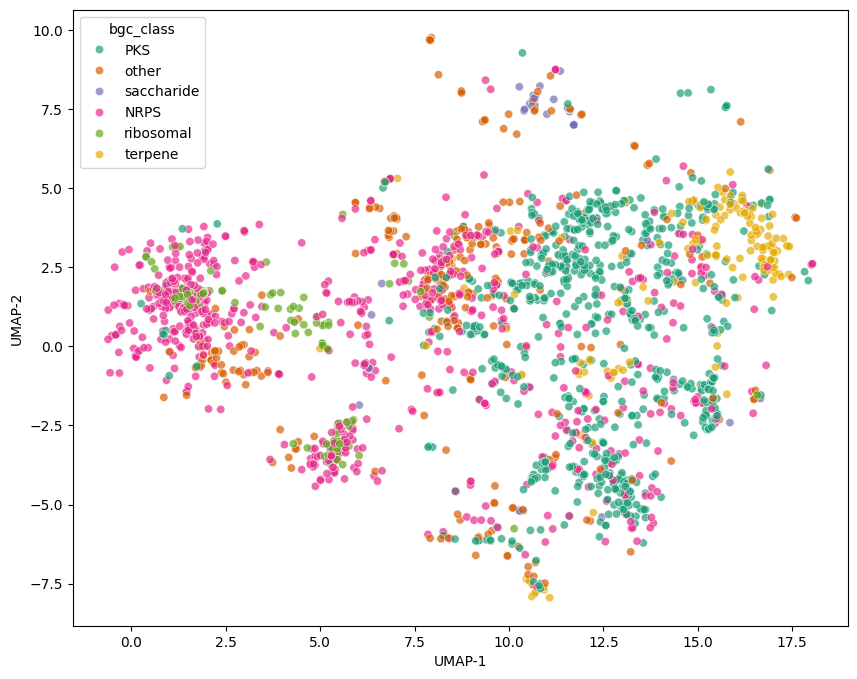

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=projection_df,
    x='UMAP-1',
    y='UMAP-2',
    hue='bgc_class',
    palette='Dark2',
    alpha=0.7
)


In [ ]:
import plotly.express as px

fig = px.scatter(
    projection_df,
    x="UMAP-1",
    y="UMAP-2",
    color="bgc_class",
    hover_data={
        "bgc_class": True,
        "compound_name": True,
        "UMAP-1": False,
        "UMAP-2": False,
    },
    opacity=0.6,
    color_discrete_sequence=px.colors.qualitative.Dark2
)

fig.update_layout(
    width=900,
    height=700,
    legend_title_text="Natural Product",
    title="Natural Products Chemical Space from MIBiG 4.0",
)

fig.show()
